Alexander W. Criswell 9/23/26

Scaffolding for normalizing flow prototyping with zuko, built on a toy single-band version of the
thresholder and a toy population model.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import sys

import numpy as np
import matplotlib.pyplot as plt
import astropy.units as u
import legwork as lw
import scipy.stats as scst
from tqdm import tqdm
from corner import corner

import torch
import zuko
import torch.utils.data as data

## pelargir modules live flat in pelargir/, imported by absolute name
sys.path.insert(0, os.path.abspath(os.path.join('..', 'pelargir')))

from utils import get_amp_freq, lisa_noise_psd, msun_kg_conv, au_m_conv, G, set_style
from thresholding import SNR_Threshold
# import flows

set_style()

print('numpy', np.__version__, '| torch', torch.__version__, '| zuko', zuko.__version__)

Running Pelargir population inference with the numpy backend.
numpy 2.3.0 | torch 2.11.0+cu130 | zuko 1.6.0


In [3]:
########################GPU Availability#########################
if torch.cuda.is_available():
    device = torch.device("cuda")
    print("GPU is available and being used")
else:
    device = torch.device("cpu")
    print("GPU is not available, using CPU instead")

GPU is available and being used


## Stupid simple starting case

Here I'll train a flow on a very simple test case. Let's assume a log-normal distribution on the binary amplitudes with its mean $\mu$ and standard deviation $\sigma$ as our population parameters, consider only one frequency bin with a fixed instrumental noise level, neglect the response, etc.. We will allow $N_{\rm tot}$ and $\rho_{\rm thresh}$ to vary. Math as follows:

$$\mu,\sigma,\lambda_{\rm tot} \sim \pi(\Lambda,\lambda_{\rm tot})$$
$$\rho_{\rm thresh} \sim \mathcal{N}(7,1)$$
$$A \sim \mathcal{N}(\mu,\sigma)$$
$$N_{\rm tot} \sim \mathrm{Poisson}(\lambda_{\rm tot})$$

In [4]:
YEAR_SECONDS = u.yr.to(u.s)

def basic_threshold(A_vec,Sn,rho_thresh):

    ## sort descending
    fbin_sort_i = np.argsort(A_vec)
    sorted_amps_i = np.take_along_axis(A_vec, fbin_sort_i)

    Nij = np.sqrt(YEAR_SECONDS*A_vec**2/((Sn + 1e-2 * YEAR_SECONDS * (np.cumsum(A_vec**2) - A_vec**2) )))
    print(Nij.max(),Nij.min(),Nij.mean())
    snr_filt = Nij>=rho_thresh
    print(snr_filt.sum())
    ## this is a very silly solution, but does work
    ## we multiply the boolean array by its indices along axis 0
    ## then by sliding the array and subtractin we can create a filter 
    ## which only registers as True only for the resolved binaries
    ## [0 0 1 0 0 1 1 1] -> [0 2 0 0 5 6 7] - [0 0 2 0 0 5 6] = [0 2 -2 0 5 1 1]
    ## argmax then returns index 4, and we filter to values > 4.
    ## As the original index 4 has to be zero to yield this result, the only
    ## entries >4 will be those after the final zero in the original array
    if sorted_amps_i.size > 1:
        tilt_filt = snr_filt*np.arange(snr_filt.size)
        res_filt = tilt_filt > np.argmax(tilt_filt[1:]-tilt_filt[:-1])
    else:
        ## cases with 1 binary
        res_filt = snr_filt
    fbin_res = np.sum(res_filt)
    foreground_amp = np.sum((sorted_amps_i*np.invert(res_filt))**2,axis=0)
    
    return fbin_res, foreground_amp

In [5]:
def run_toy_sim():

    Sn = 10**-40

    loglambdadist = scst.uniform(loc=2,scale=3)
    
    loglambda_true = 5e3
    N_true = scst.poisson(mu=loglambda_true).rvs()
    
    logAmu_true = -27
    logAsigma_true = 4
    logAdist_true = scst.norm(logAmu_true,logAsigma_true)

    rho_true = 7

    Avec = 10**logAdist_true.rvs(N_true)
    print(Avec.min(),Avec.max())

    sim_Nres, sim_fg = basic_threshold(Avec,Sn,rho_true)
    
    return sim_Nres, sim_fg


def run_toy_model():


    Ndist = scst.poisson(mu=10000)

    rhodist = scst.norm(7,1)
    
    return

In [6]:
Ntest, fgtest = run_toy_sim()

6.355318337577631e-42 1.2080349606618746e-11
6245.530851240677 1.7477828103538479e-29 2.204368792571661
8


In [7]:
Ntest, fgtest

(np.int64(1), np.float64(1.4596293837770437e-22))

In [8]:
def run_sim(rate=1e4,Afac_mu=20000,Afac_sigma=200,rho=7):
    Sn = 10**-40

    Ntot = scst.poisson(mu=rate).rvs()

    Adist = scst.norm(Afac_mu,Afac_sigma)
    
    A_vec = 10**-26 * Adist.rvs(Ntot)
    
    # sim_Nres, sim_fg = basic_threshold(Avec,Sn,rho_true)
    
    ## sort descending
    fbin_sort_i = np.argsort(A_vec)
    sorted_amps_i = np.take_along_axis(A_vec, fbin_sort_i)
    
    Nij = np.sqrt(YEAR_SECONDS*A_vec**2/((Sn + 1e-3*YEAR_SECONDS*(np.cumsum(A_vec**2) - A_vec**2) )))
    # print(Nij.max(),Nij.min(),Nij.mean())
    snr_filt = Nij>=rho
    # print(snr_filt.sum())
    ## this is a very silly solution, but does work
    ## we multiply the boolean array by its indices along axis 0
    ## then by sliding the array and subtractin we can create a filter 
    ## which only registers as True only for the resolved binaries
    ## [0 0 1 0 0 1 1 1] -> [0 2 0 0 5 6 7] - [0 0 2 0 0 5 6] = [0 2 -2 0 5 1 1]
    ## argmax then returns index 4, and we filter to values > 4.
    ## As the original index 4 has to be zero to yield this result, the only
    ## entries >4 will be those after the final zero in the original array
    if sorted_amps_i.size > 1:
        tilt_filt = snr_filt[::-1]*np.arange(snr_filt.size)
        res_filt = tilt_filt > np.argmax(tilt_filt[1:]-tilt_filt[:-1])
    else:
        ## cases with 1 binary
        res_filt = snr_filt
    fbin_res = np.sum(res_filt)
    foreground_amp = np.sum((sorted_amps_i*np.invert(res_filt))**2,axis=0)

    return fbin_res, foreground_amp

In [9]:
Ntest, fgtest = run_sim()

In [10]:
Ntest,fgtest

(np.int64(21), np.float64(4.001949432415942e-40))

In [11]:
def run_model(Nsamp):

    Afac_hyperprior = scst.uniform(loc=1000,scale=29000)
    Asigma_hyperprior = scst.uniform(loc=50,scale=450)
    rho_prior = scst.norm(loc=8,scale=2)
    lograte_hyperprior = scst.uniform(2,2.3)
    
    param_vec = np.zeros((6,Nsamp))

    Afacs = Afac_hyperprior.rvs(Nsamp)
    Asigmas = Asigma_hyperprior.rvs(Nsamp)
    rhos = rho_prior.rvs(Nsamp)
    rates = 10**lograte_hyperprior.rvs(Nsamp)

    param_vec[0,:] = Afacs
    param_vec[1,:] = Asigmas
    param_vec[2,:] = rhos
    param_vec[3,:] = rates

    for i in tqdm(range(Nsamp)):
        ## Nres, fg
        param_vec[4,i], param_vec[5,i] = run_sim(rate=rates[i],Afac_mu=Afacs[i],Afac_sigma=Asigmas[i],rho=rhos[i])
    param_vec[5,:] = np.log10(param_vec[5,:])
    return param_vec
    

In [12]:
param_vec = run_model(500000)

100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 500000/500000 [04:58<00:00, 1672.67it/s]


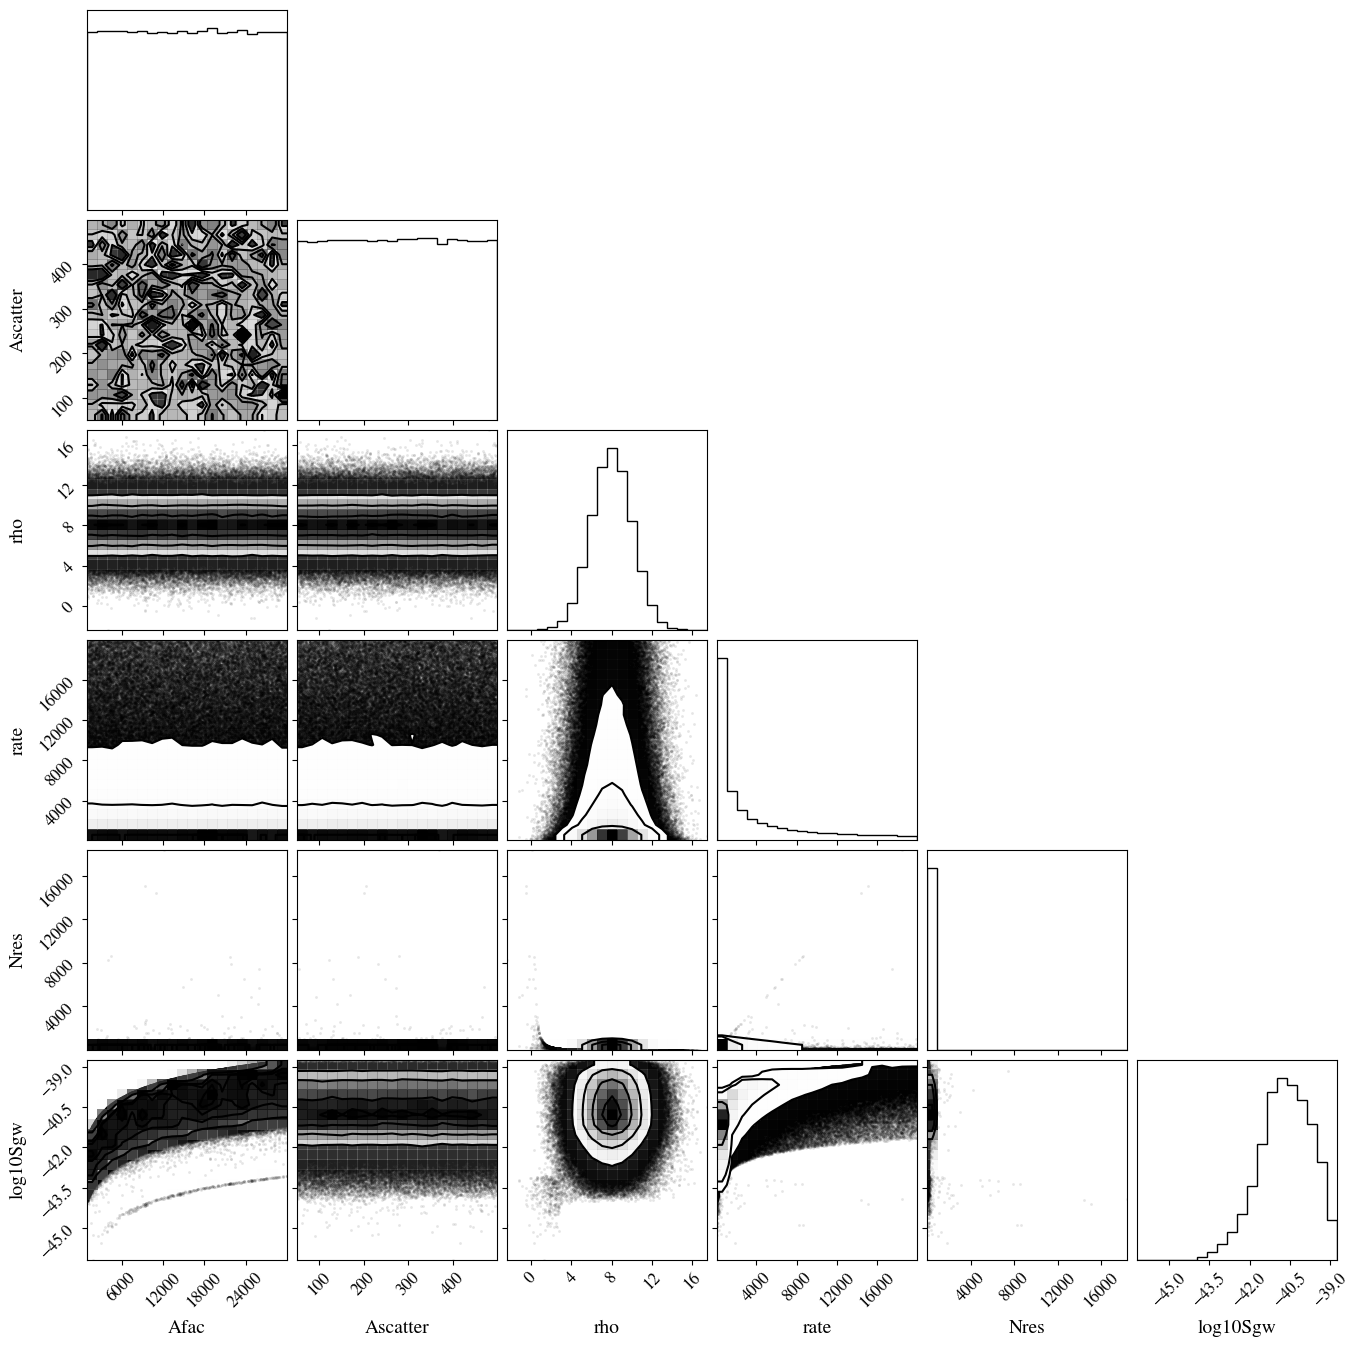

In [13]:
corner(param_vec.T,labels=['Afac','Ascatter','rho','rate','Nres','log10Sgw'])
plt.show()

Cool, the super basic model is working. Let's work on the transforms.

In [14]:
def transform(in_vec):

    base_vec = in_vec.copy()
    
    ## dequantize Nres
    base_vec[-2,:] = base_vec[-2,:] + scst.uniform().rvs(base_vec[-2,:].size)

    ## rate, dequantized Nres, and Sgw in log space
    if np.any(base_vec[-1,:]>0):
        base_vec[-1,:] = np.log10(base_vec[-1,:])
    base_vec[-2,:] = np.log10(base_vec[-2,:])
    base_vec[-3,:] = np.log10(base_vec[-3,:])
    
    
    ## basic standardizing transform
    meds = np.median(base_vec,axis=1)
    halfrange = (base_vec.max(axis=1) - base_vec.min(axis=1))/2
    trans_vec = (base_vec - meds[:,None])/halfrange[:,None]

    
    ## pass everything to torch tensors
    trans_vec_device = torch.tensor(trans_vec, device = device, dtype=torch.float32)

    return trans_vec_device, [meds, halfrange]

def inverse_transform(z_vec,shift,delog=[0,1],quantized=[0]):
    '''
    z_vec is in the transformed space

    shift is [loc, scale] from the original transform

    delog indicates which variables are in log10 coords

    quantized indicates which variables need to be mapped back to integers
    
    '''

    trans_vec = z_vec.copy()

    base_vec = shift[1][4:,None]*z_vec + shift[0][4:,None]

    for i in delog:
        base_vec[i,:] = 10**base_vec[i,:]

    for i in quantized:
        base_vec[i,:] = np.floor(base_vec[i,:])

    return base_vec

def inverse_transform_full(z_vec,shift,delog=[3,4],quantized=[4]):
    '''
    z_vec is in the transformed space

    shift is [loc, scale] from the original transform

    delog indicates which variables are in log10 coords

    quantized indicates which variables need to be mapped back to integers
    
    '''

    trans_vec = z_vec.copy()

    base_vec = shift[1][:,None]*z_vec + shift[0][:,None]

    for i in delog:
        base_vec[i,:] = 10**base_vec[i,:]

    for i in quantized:
        base_vec[i,:] = np.floor(base_vec[i,:])

    return base_vec

In [15]:
test_vec, shift = transform(param_vec)
out_vec = inverse_transform_full(test_vec.cpu().numpy(),shift)

In [16]:
param_vec[4,:10],out_vec[4,:10]

(array([ 15.,  79.,  21.,  19.,  27.,  19.,  10.,  26., 131.,  13.]),
 array([ 15.,  79.,  21.,  19.,  27.,  19.,  10.,  26., 131.,  13.]))

In [17]:
test_vec[-2,:].min(),test_vec[-2,:].max()

(tensor(-1.2298, device='cuda:0'), tensor(0.7702, device='cuda:0'))

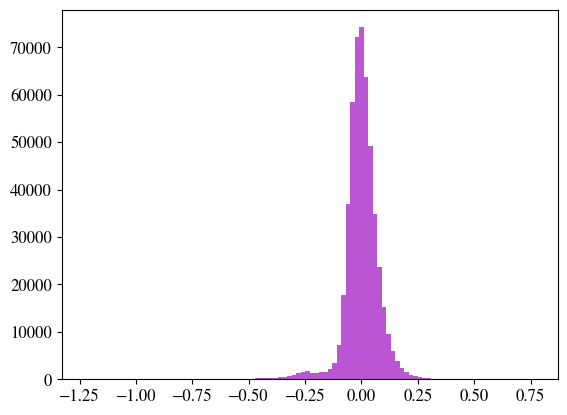

In [18]:
plt.hist(test_vec[-2,:].cpu().numpy(),bins=100)
plt.show()

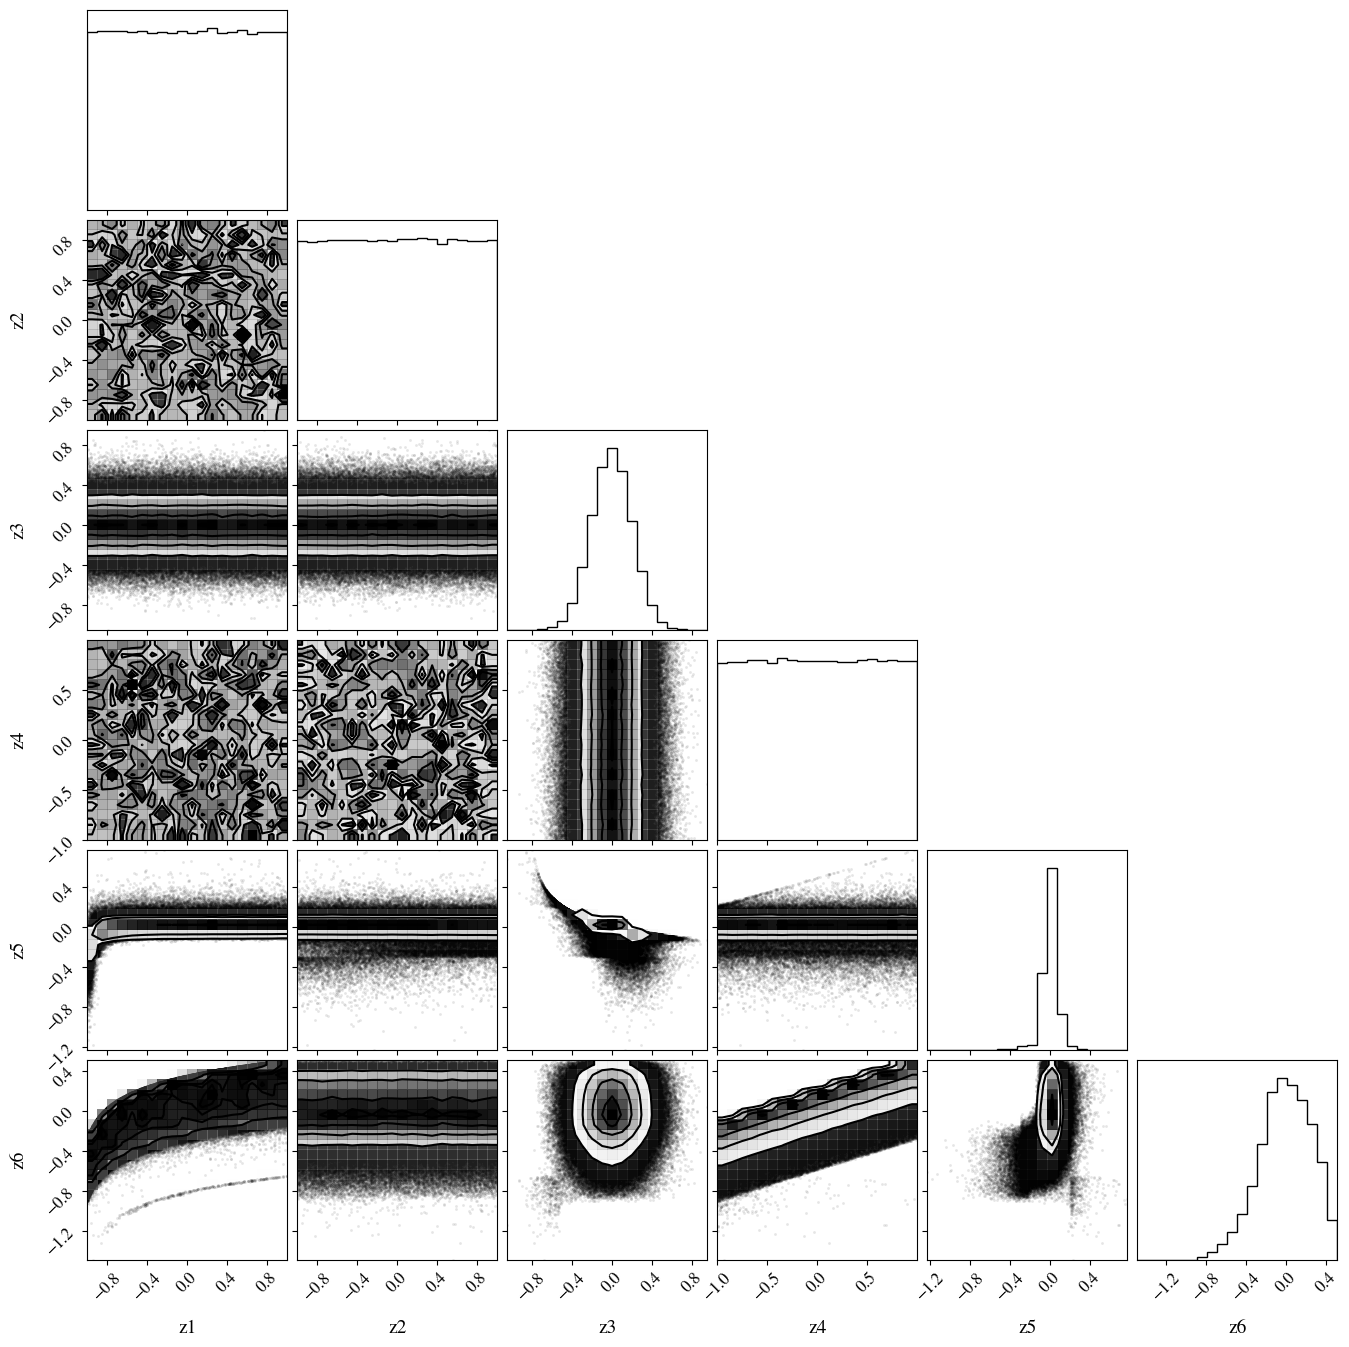

In [19]:
corner(test_vec.T.cpu().numpy(),labels=['z'+str(i+1) for i in range(6)])
plt.show()

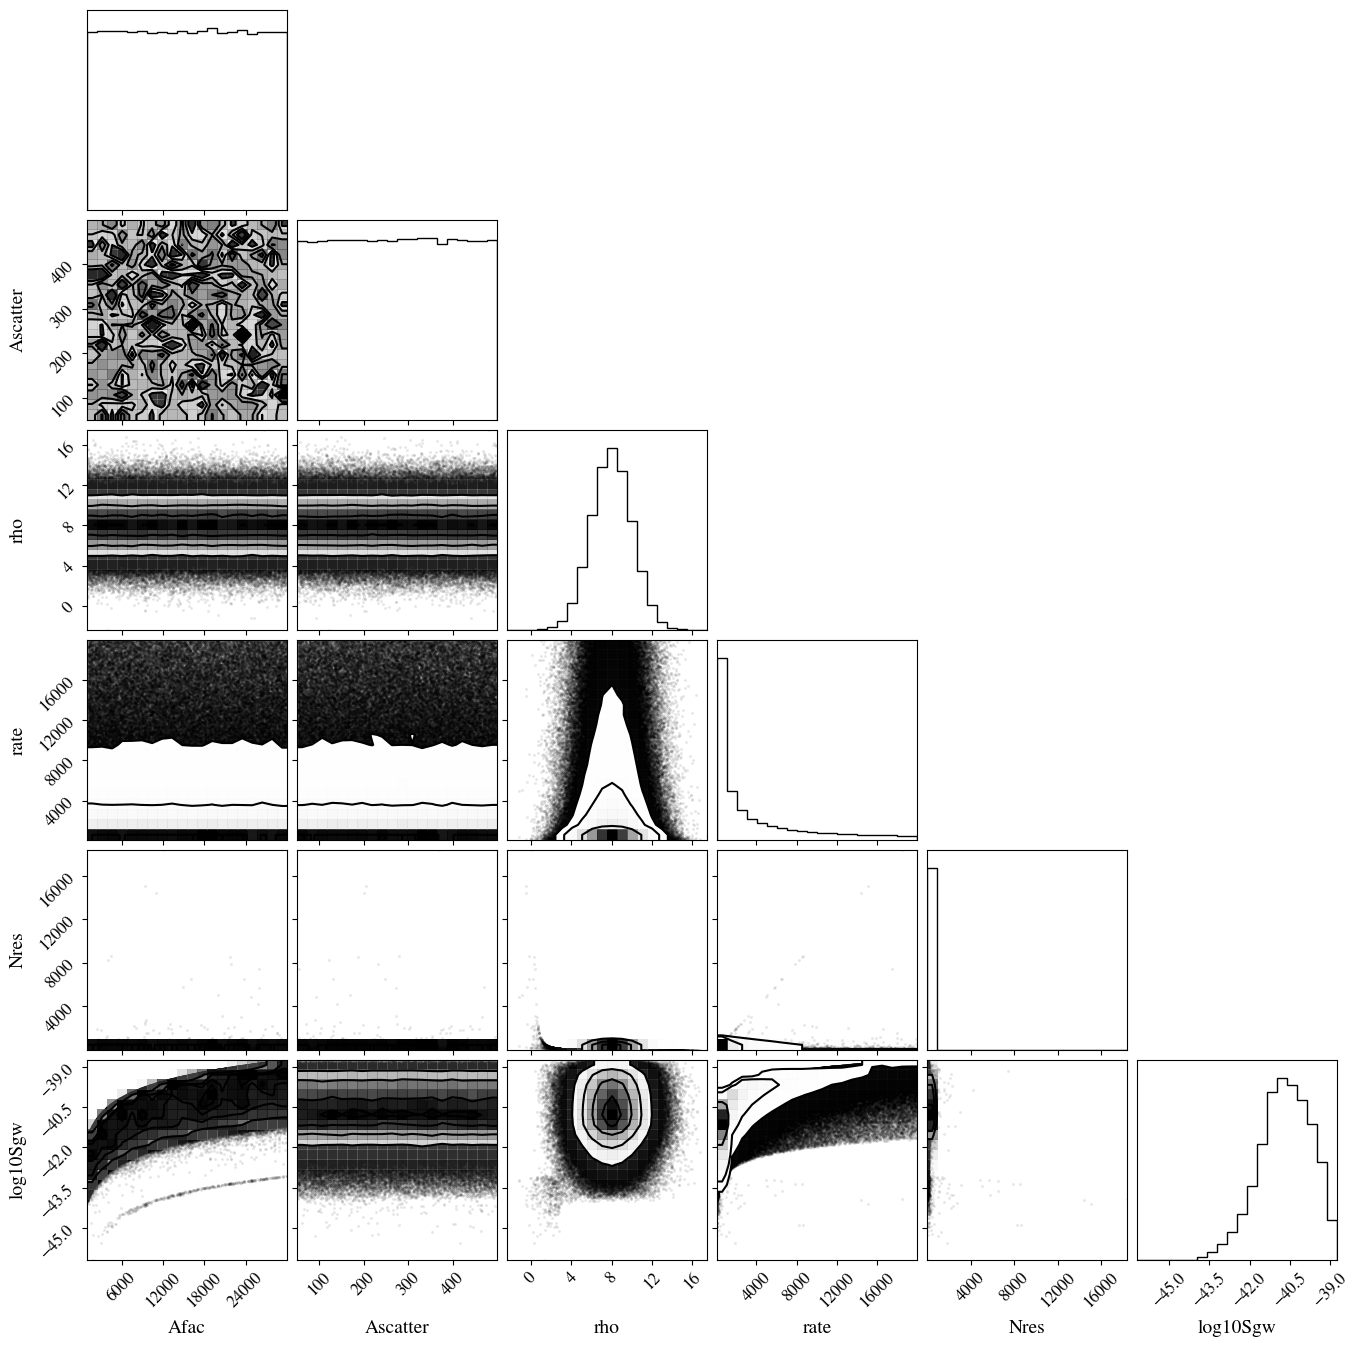

In [20]:
corner(out_vec.T,labels=['Afac','Ascatter','rho','rate','Nres','log10Sgw'])
plt.show()

In [21]:
np.allclose(out_vec,param_vec)

True

Woo! Transform and inverse transform working properly. Now let's build the flow.

In [22]:
test_vec.shape

torch.Size([6, 500000])

In [23]:
trainset = data.TensorDataset(test_vec[4:,:].T,test_vec[:4,:].T) ## samples, labels
trainloader = data.DataLoader(trainset, batch_size=64, shuffle=True)

In [24]:
## setup
input_dim = 2 ## Nres, Sgw
count_bins = 16
context_dim = 4 ## pop params + rho
hidden_dims = [input_dim * 10, input_dim * 10]
param_dims = [count_bins, count_bins, count_bins]

In [25]:
# Neural spline flow (NSF)
flow = zuko.flows.NSF(input_dim, context_dim, transforms=3, hidden_features=hidden_dims).to(device)

In [26]:
flow

NSF(
  (transform): LazyComposedTransform(
    (0): MaskedAutoregressiveTransform(
      (base): MonotonicRQSTransform(bins=8)
      (order): [0, 1]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=6, out_features=20, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=20, out_features=20, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=20, out_features=46, bias=True)
      )
    )
    (1): MaskedAutoregressiveTransform(
      (base): MonotonicRQSTransform(bins=8)
      (order): [1, 0]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_features=6, out_features=20, bias=True)
        (1): ReLU()
        (2): MaskedLinear(in_features=20, out_features=20, bias=True)
        (3): ReLU()
        (4): MaskedLinear(in_features=20, out_features=46, bias=True)
      )
    )
    (2): MaskedAutoregressiveTransform(
      (base): MonotonicRQSTransform(bins=8)
      (order): [0, 1]
      (hyper): MaskedMLP(
        (0): MaskedLinear(in_featur

In [27]:
## train
optimizer = torch.optim.Adam(flow.parameters(), lr=1e-3)
for epoch in range(8):
    losses = []

    for x, label in trainloader:
        c = label

        loss = -flow(c).log_prob(x).mean()
        loss.backward()

        optimizer.step()
        optimizer.zero_grad()

        losses.append(loss.detach())

    losses = torch.stack(losses)

    print(f"({epoch})", losses.mean().item(), "±", losses.std().item())

(0) -6.994707107543945 ± 0.9570211172103882
(1) -7.51235294342041 ± 0.27019333839416504
(2) -7.596527576446533 ± 0.2751292586326599
(3) -7.641681671142578 ± 0.2669343054294586
(4) -7.67908239364624 ± 0.2556542158126831
(5) -7.706811904907227 ± 0.25218746066093445
(6) -7.720545291900635 ± 0.24665047228336334
(7) -7.730198383331299 ± 0.248230442404747


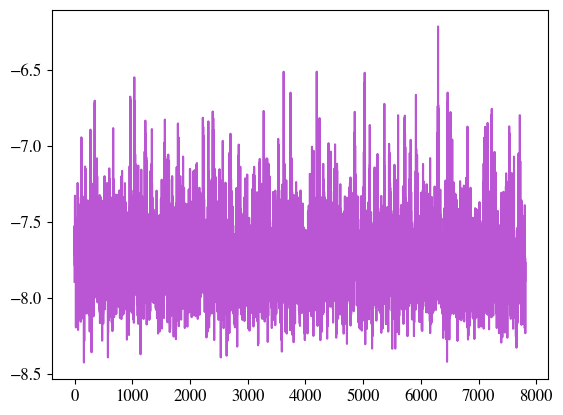

In [28]:
plt.figure()
plt.plot(losses.cpu())
plt.show()

In [30]:
# Nsamp = 50000
# flow_samps = np.zeros((Nsamp,2))
# idxs = np.arange(Nsamp)
# for i in tqdm(range(Nsamp)):
#     draw_idx = np.random.choice(idxs)
#     flow_samps[i,:] = flow(test_vec[:4,draw_idx].T).sample((1,)).cpu().numpy()

In [32]:
parallel_samps = flow(test_vec[:4,:].T).sample().cpu().numpy()
parallel_samps.shape

(500000, 2)

In [33]:
# trans_samps = inverse_transform(flow_samps.T,shift,delog=[0])
trans_parallel_samps = inverse_transform(parallel_samps.T,shift,delog=[0])

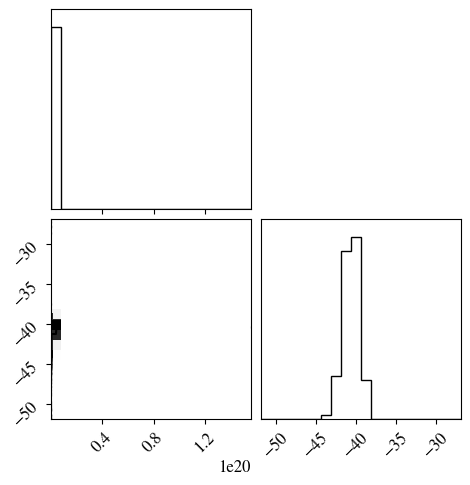

In [35]:
corner(trans_parallel_samps.T)
plt.show()

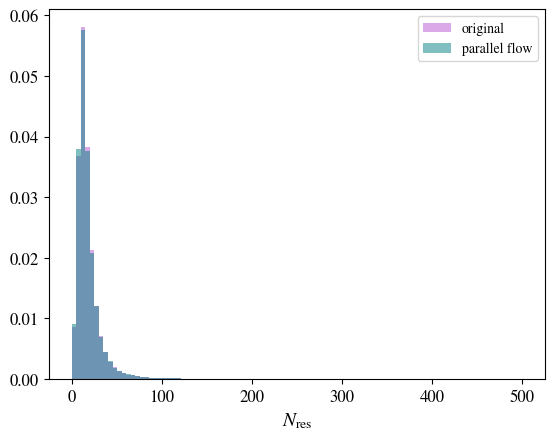

In [37]:
plt.figure()
plt.hist(param_vec[-2,:].T,bins=np.linspace(0,500,100),label='original',density=True,alpha=0.5)
# plt.hist(trans_samps[0,:].T,bins=np.linspace(0,500,100),label='flow',density=True,alpha=0.5)
plt.hist(trans_parallel_samps[0,:].T,bins=np.linspace(0,500,100),label='parallel flow',density=True,alpha=0.5)
plt.xlabel(r'$N_{\rm res}$')
plt.legend()
plt.show()

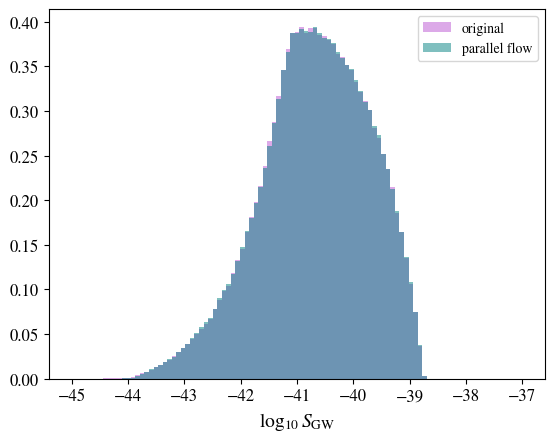

In [38]:
plt.figure()
plt.hist(param_vec[-1,:].T,bins=np.linspace(-45,-37,100),label='original',density=True,alpha=0.5)
# plt.hist(trans_samps[1,:].T,bins=np.linspace(-45,-37,100),label='flow',density=True,alpha=0.5)
plt.hist(trans_parallel_samps[1,:].T,bins=np.linspace(-45,-37,100),label='parallel flow',density=True,alpha=0.5)
plt.xlabel(r'$\log_{10}S_{\rm GW}$')
plt.legend()
plt.show()

Nice!

In [39]:
shift[0].shape

(6,)

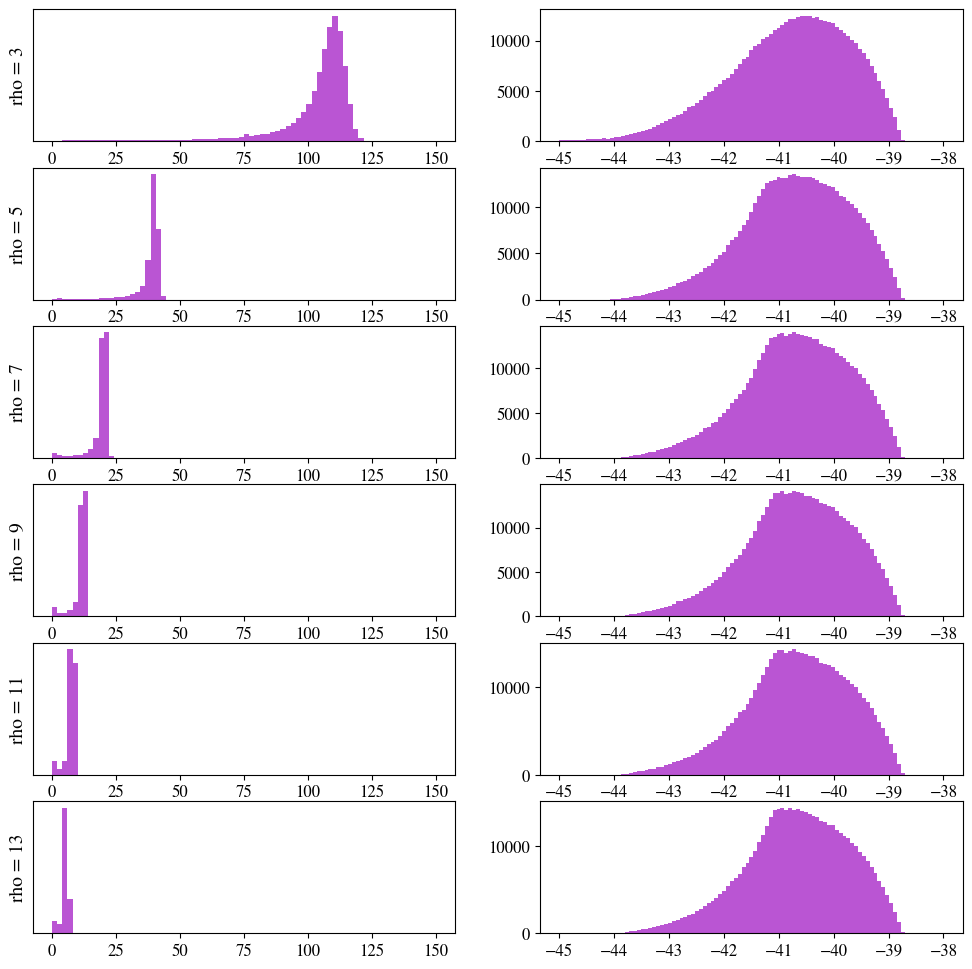

In [46]:
## as a function of rho_thresh
rhos = [3,5,7,9,11,13]
fig, axes = plt.subplots(6,2,figsize=(12,12))
for i, rho in enumerate(rhos):
    temp_vec = test_vec[:4,:].T
    temp_vec[:,2] = (rho - shift[0][2])/shift[1][2]
    parallel_samps = flow(temp_vec).sample().cpu().numpy()
    trans_parallel_samps = inverse_transform(parallel_samps.T,shift,delog=[0])
    axes[i,0].hist(trans_parallel_samps.T[:,0],bins=np.linspace(0,150,75))
    axes[i,1].hist(trans_parallel_samps.T[:,1],bins=np.linspace(-45,-38,100))
    axes[i,0].set_yticks([])
    axes[i,0].set_ylabel('rho = {}'.format(rho))

Behaving as expected, good. Next up: implement this for the full pelargir thresholder model, think about how to optimize frequency bands.